# 学習なしループを1ステップずつ実証する（自己完結版）

会話記録の最後で説明した仕組み **「種 → 広げる → 確かめる → 分ける」** を、
関節リウマチ（RA）の18遺伝子デモで順番に実行します。

## このノートの方針

- **外部の .py ファイルは参照しません。** ルール・質問文・記録データ・採点・対戦・ループの処理は、すべてこのノートのセルに書いてあります。
  読めば何をしているかが分かるように、処理は `def` にまとめず、そのまま書いています。
- `def` は4つだけ使います（選択肢の log 確率を読む `option_logprobs` / AI に「はい」の確率を聞く / AI に文章で答えさせる / 文章から遺伝子記号を取り出す）。
- モデルは **`~/llm/models` の GGUF** と **Ollama** のどちらでも使えます（設定セルで一覧から選択）。GGUF は **guidance** ライブラリで動かします（`select` で答えを選択肢に限り、制約前の top_k から確率を読む、お使いの `option_logprobs` 方式）。
  同じ処理を何十回も呼ぶため、そこだけは関数にしました。それぞれの直前に「どんな def か・各ステップが何をして何を返すか」を説明しています。
- セルは上から順に実行してください。前のセルで作った変数を次のセルが使います。
- 各コードセルの直前に **「このセルがすること」** を書いてあります。

## 仕組みの全体像（中学生向け）

| 段階 | たとえ | このノートでの場所 |
|---|---|---|
| 種 | 「この病気で確実に効く薬の相手」をAIに思い出させ、逆引きで確かめる | ステップ1 |
| 広げる | 種の「知り合い」を探す（直接の相手・上流・下流・同じ仕事・住所が近い） | ステップ2 |
| 確かめる | 短い質問を6回ずつ聞いて「はい」の確率を平均し、逆からも聞く | ステップ3・4 |
| 分ける | 既知／しくみが近い／地図が近い／逆効果 に分けて根拠を付ける | ステップ6 |

> 注意：記録の答えは Claude が5段階の確信度で判定したもので、臨床結果を知っている「後知恵」が混ざっています。
> このノートは**手順が設計どおりに動くこと**を示すもので、性能の証明ではありません。

### このセルがすること：準備
- 標準ライブラリと pandas / matplotlib だけを読み込みます。自作の .py は読み込みません。

In [1]:
import os, re, math, itertools
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
print("ready")

ready


### このセルがすること：設定（病気と AI 役の選択）
- **モデルの選択**：`~/llm/models` の GGUF と、起動中の Ollama のモデルを一覧にして選びます。
  `BACKEND`（auto / gguf / ollama / mock）と `MODEL_SELECT`（auto / 一覧の番号 / 名前の一部）で指定します。
  auto なら txgemma → medgemma → gemma の順で優先。`BACKEND = "mock"` にすると会話記録の答えを再生します。
- 病名と組織名は、あとで質問文の `{disease}` `{tissue}` に入ります。

In [2]:
import glob, json, urllib.request
DISEASE = "rheumatoid arthritis"
TISSUE  = "synovium (joint)"

# --- モデルの選択 ---
# BACKEND: "auto" = Ollama が起動していれば Ollama、無ければ ~/llm/models の GGUF、それも無ければモック
#          "gguf" / "ollama" / "mock" で固定もできる
BACKEND = "auto"
MODEL_DIR = os.path.expanduser("~/llm/models")            # GGUF の置き場所
OLLAMA_URL = "http://localhost:11434"                     # Ollama サーバー
MODEL_SELECT = "auto"                                     # "auto" / 一覧の番号（例 2）/ 名前の一部（例 "medgemma"）
PREFER = ("txgemma", "medgemma", "gemma")                 # auto のとき、この順で名前に含むものを優先
TOP_K = 50                                                # 確率読みで記録する上位トークン数

# 使えるモデルを集める（GGUF ファイルと Ollama のモデル）
models = []
for h in sorted(glob.glob(os.path.join(MODEL_DIR, "**", "*.gguf"), recursive=True)):
    models.append({"kind": "gguf", "name": os.path.basename(h), "path": h, "size_gb": round(os.path.getsize(h) / 1e9, 2)})
try:
    with urllib.request.urlopen(OLLAMA_URL + "/api/tags", timeout=3) as r:
        for m in json.load(r).get("models", []):
            models.append({"kind": "ollama", "name": m["name"], "path": m["name"], "size_gb": round(m.get("size", 0) / 1e9, 2)})
except Exception:
    pass                                                   # Ollama が起動していない

# 選ぶ
chosen = None
if BACKEND == "mock":
    pass
elif isinstance(MODEL_SELECT, int):
    chosen = models[MODEL_SELECT]
else:
    pool = [m for m in models if BACKEND == "auto" or m["kind"] == BACKEND]
    if MODEL_SELECT != "auto":
        pool = [m for m in pool if MODEL_SELECT.lower() in m["name"].lower()]
    ranked = sorted(pool, key=lambda m: (min([i for i, p in enumerate(PREFER) if p in m["name"].lower()] or [99]),
                                         0 if m["kind"] == "ollama" else 1, m["name"]))
    chosen = ranked[0] if ranked else None
USE_LLM = chosen is not None
BACKEND_USED = chosen["kind"] if chosen else "mock"
MODEL_PATH = chosen["path"] if chosen else None            # GGUF ならファイルパス、Ollama ならモデル名

print("使えるモデル:")
for i, m in enumerate(models): print(f"  [{i}] {m['kind']:6s} {m['size_gb']:6.2f} GB  {m['name']}")
print("選択:", f"{BACKEND_USED}: {MODEL_PATH}" if USE_LLM else "記録の再生（Claude が判定した答え）")

使えるモデル:
選択: 記録の再生（Claude が判定した答え）


## ステップ0：点数のルールを先に決めて固定する（学習なし）

```
Q = 質問の「はい」確率の平均（副作用 Q5 は 1−p）
P = max( M, 0.8×N, 0.6×V )      M:しくみの近さ  N:関係の網の近さ  V:地図の近さ
総合 = Q × P × 0.7^(回数−1)
逆向き・矛盾 → 点数に関係なく別枠
```

### このセルがすること：ルールの定数を変数として宣言し、表にする
- ここに書いた数字は、結果を見た後に変えません（変えると人が学習しているのと同じになります）。

In [3]:
M_SAME, M_ADJ, M_OFF = 1.0, 0.7, 0.0        # M: 同じ段階 / 隣の段階 / 鎖に乗らない
N_DIRECT, N_TWOHOP, N_FAR = 1.0, 0.5, 0.0   # N: 既知から 1段 / 2段 / それ以上
V_NEAR, V_MID, V_FAR = 1.0, 0.5, 0.0        # V: 地図で 近 / 中 / 遠
W_NET, W_VEC = 0.8, 0.6                     # P = max(M, W_NET×N, W_VEC×V)
DAMPING = 0.7                               # 2回目以降の候補に掛ける減衰
MAX_ROUNDS = 3                              # ループの最大回数
STOP_TOPK = 5                               # 上位5件の顔ぶれが変わらなければ停止
PAIR_TOPK = 4                               # 対戦比較に進む上位件数
pd.DataFrame({"rule": ["M_SAME","M_ADJ","N_DIRECT","N_TWOHOP","V_NEAR","V_MID","W_NET","W_VEC","DAMPING","MAX_ROUNDS","STOP_TOPK","PAIR_TOPK"],
              "value": [M_SAME,M_ADJ,N_DIRECT,N_TWOHOP,V_NEAR,V_MID,W_NET,W_VEC,DAMPING,MAX_ROUNDS,STOP_TOPK,PAIR_TOPK]})

,rule,value
0,M_SAME,1.0
1,M_ADJ,0.7
2,N_DIRECT,1.0
3,N_TWOHOP,0.5
4,V_NEAR,1.0
5,V_MID,0.5
6,W_NET,0.8
7,W_VEC,0.6
8,DAMPING,0.7
9,MAX_ROUNDS,3.0


### このセルがすること：5つの質問（＋任意の Q6）を書く
- 各質問は本文と言い換え2通りの計3通り。`{gene}` `{disease}` `{tissue}` は実行時に置き換えます。
- `invert=True` の質問（Q5 副作用）は、答えを 1−p にして「副作用が少ないほど高得点」にします。

In [4]:
QUESTIONS = [
  {"qid":"Q1","invert":False,"texts":[
     "Is the gene {gene} expressed or active in the affected tissue ({tissue}) of {disease}?",
     "Is {gene} up-regulated or functionally active in {tissue} in patients with {disease}?",
     "In {disease}, does the gene {gene} play an active role in the {tissue}?"]},
  {"qid":"Q2","invert":False,"texts":[
     "Is {gene} part of the disease mechanism chain of {disease} (i.e. does it act at one of the stages of the pathogenic cascade)?",
     "Does {gene} act at a defined step of the pathogenic cascade of {disease}?",
     "Can {gene} be placed on the cause-to-symptom pathway of {disease}?"]},
  {"qid":"Q3","invert":False,"texts":[
     "Would inhibiting {gene} be expected to improve the symptoms of {disease}?",
     "Is blocking {gene} expected to reduce disease activity in {disease}?",
     "Does loss or inhibition of {gene} ameliorate {disease}?"]},
  {"qid":"Q4","invert":False,"texts":[
     "Is {gene} a druggable protein class (enzyme, receptor, secreted or cell-surface protein) that a small molecule or antibody could target?",
     "Does {gene} belong to a protein class that is readily targeted by drugs (enzyme, receptor, ion channel, secreted or membrane protein)?",
     "Is the protein encoded by {gene} accessible to small molecules or antibodies?"]},
  {"qid":"Q5","invert":True,"texts":[
     "Would inhibiting {gene} be expected to cause serious adverse effects (e.g. severe infection, cytopenia, organ toxicity)?",
     "Is systemic inhibition of {gene} likely to cause serious safety problems?",
     "Is {gene} essential for functions whose loss causes severe toxicity?"]},
  {"qid":"Q6","invert":False,"texts":[      # 任意：ヒト遺伝学の証拠（デモ後に提案された質問）
     "Do common or rare genetic variants in {gene} alter the risk of {disease} in humans (GWAS or Mendelian evidence)?",
     "Is {gene} a human-genetics-supported locus for {disease}?",
     "Has human genetic evidence linked {gene} to susceptibility to {disease}?"]},
]
QIDS = ["Q1", "Q2", "Q3", "Q4", "Q5"]          # 採点に使う質問（Q6 は検証2で使う）
pd.DataFrame([{"qid": q["qid"], "invert": q["invert"], "question": q["texts"][0]} for q in QUESTIONS])

,qid,invert,question
0,Q1,False,Is the gene {gene} expressed or active in the ...
1,Q2,False,Is {gene} part of the disease mechanism chain ...
2,Q3,False,Would inhibiting {gene} be expected to improve...
3,Q4,False,"Is {gene} a druggable protein class (enzyme, r..."
4,Q5,True,Would inhibiting {gene} be expected to cause s...
5,Q6,False,Do common or rare genetic variants in {gene} a...


### このセルがすること：病気のしくみの鎖と、文章で答えさせる質問の雛形を書く
- 鎖は S1（引き金）→ S7（症状）の7段。どの段も「止めると症状が良くなる」向き（WORSE）です。
- 雛形は、種の検証・候補の拡張・段階と向き・地図の近さ・反論役・対戦比較に使います。

In [5]:
CHAIN = [("S1","antigen presentation and T-cell activation"), ("S2","B cells and autoantibodies"),
         ("S3","innate immune signalling"), ("S4","inflammatory cytokines and their receptors"),
         ("S5","intracellular signalling (JAK-STAT)"), ("S6","synovial proliferation and osteoclast activation"),
         ("S7","joint destruction (symptom)")]
STAGE_INDEX = {sid: i for i, (sid, _) in enumerate(CHAIN)}     # S1→0, S2→1, …（段階の距離を数えるため）
STAGE_NAME  = dict(CHAIN)
CHAIN_TEXT  = "\n".join(f"{sid}: {name}" for sid, name in CHAIN)

# --- 文章で答えさせる質問の雛形 ---
SEED_DRUG_CHECK   = "Name an approved drug for {disease} whose molecular target is {gene}. If none exists, answer NONE."
DRUG_TARGET       = "What is the molecular target (human gene symbol) of the drug {drug}? Answer with official gene symbols separated by commas only."
REVERSE_DRUG      = "Is there an approved drug whose molecular target is {gene}, approved for {disease} in any country? Answer Yes or No."
PARTNERS_PROMPT   = "List the human genes whose protein products directly bind to, are the receptor or ligand of, or are in the same complex as {gene}. Answer with official gene symbols separated by commas only."
UPSTREAM_PROMPT   = "List the human genes that act immediately upstream of {gene} in its signalling pathway. Answer with official gene symbols separated by commas only."
DOWNSTREAM_PROMPT = "List the human genes that act immediately downstream of {gene}, i.e. whose expression or activity is increased by {gene}. Answer with official gene symbols separated by commas only."
MAP_PROMPT        = "List the human genes whose biological function is most similar to {gene} (paralogs, same family, same complex). Answer with official gene symbols separated by commas only."
SAME_STAGE_PROMPT = "In the pathogenesis of {disease}, stage '{stage}' involves these genes: {seeds}. List other human genes that act at the same stage and in the same direction. Answer with official gene symbols separated by commas only."
STAGE_PROMPT      = "The mechanism of {disease} can be described as the following chain of stages:\n{chain}\nAt which stage does {gene} act? Answer with the stage id only (e.g. S3), or NONE if it is not on this chain."
DIRECTION_PROMPT  = "In {disease}, does the activity of {gene} make the disease WORSE (so inhibiting it would help) or BETTER (so inhibiting it would harm)? Answer with WORSE or BETTER only."
REVERSE_STAGE     = "In the pathogenesis of {disease}, is the stage '{stage}' the step at which {gene} acts?"
VECTOR_JUDGE      = "How similar is the biological function of {gene} to the validated {disease} targets {seeds}? Answer NEAR, MID or FAR only."
CRITIC_PROMPT     = "You are a sceptical reviewer. Give the three strongest reasons why {gene} could FAIL as a drug target for {disease}. Be concise."
PAIRWISE_PROMPT   = "Which gene is the more plausible drug target for {disease}: {a} or {b}? Answer with the gene symbol only."
pd.DataFrame(CHAIN, columns=["stage", "content"])

,stage,content
0,S1,antigen presentation and T-cell activation
1,S2,B cells and autoantibodies
2,S3,innate immune signalling
3,S4,inflammatory cytokines and their receptors
4,S5,intracellular signalling (JAK-STAT)
5,S6,synovial proliferation and osteoclast activation
6,S7,joint destruction (symptom)


## 記録データ（会話記録の転記）

### このセルがすること：会話記録で Claude が答えた内容を、読みやすい表として書く
- `RECORDED_ANSWERS`：遺伝子 × [Q1, Q2, Q3, Q4, Q5（副作用の生の確率）, Q6]。値は 1.0 / 0.75 / 0.5 / 0.25 / 0 の5段階。
- `ANNOT`：段階・向き・地図の近さ（Claude の判定）。
- 拡張リスト（`PARTNERS` など）は会話記録の18遺伝子に刈り込んであります。本物のLLMではもっと出ます。
- 2回目の候補（CSF2RA, IL6ST, MYD88）の質問ごとの答えは会話記録に無いため、報告された Q（0.95, 0.80, 0.65）に合うよう再構成しています。

In [6]:
SEEDS_PROPOSED = ["CTLA4", "MS4A1", "TNF", "IL6R", "JAK1"]           # AI が最初に挙げた種（CTLA4 は後で直る）
SEED_DRUG   = {"CTLA4":"abatacept","MS4A1":"rituximab","TNF":"adalimumab","IL6R":"tocilizumab","JAK1":"upadacitinib","CD80":"abatacept"}
DRUG_TARGET_ANS = {"abatacept":"CD80, CD86","rituximab":"MS4A1","adalimumab":"TNF","tocilizumab":"IL6R","upadacitinib":"JAK1"}

RECORDED_ANSWERS = {   #  Q1    Q2    Q3    Q4    Q5    Q6
    "IL6":      [1.0,  1.0,  1.0,  1.0,  0.25, 0.75],
    "CSF2":     [1.0,  1.0,  1.0,  1.0,  0.25, 0.25],
    "TNFRSF1A": [1.0,  1.0,  1.0,  1.0,  0.50, 0.25],
    "TYK2":     [0.75, 1.0,  1.0,  1.0,  0.25, 1.0 ],
    "BTK":      [0.75, 1.0,  1.0,  1.0,  0.25, 0.25],
    "IL17A":    [0.75, 0.75, 1.0,  1.0,  0.25, 0.25],
    "TNFSF11":  [1.0,  1.0,  1.0,  1.0,  0.25, 0.25],
    "IRAK4":    [0.75, 1.0,  1.0,  1.0,  0.50, 0.25],
    "IL11":     [0.5,  0.5,  0.5,  1.0,  0.50, 0.0 ],
    "IL10":     [1.0,  1.0,  0.0,  1.0,  0.50, 0.25],
    "CSF2RA":   [1.0,  1.0,  1.0,  1.0,  0.25, 0.25],
    "IL6ST":    [1.0,  1.0,  1.0,  1.0,  1.00, 0.25],
    "MYD88":    [0.75, 1.0,  1.0,  0.25, 0.75, 0.0 ],
}
ANNOT = {  # gene: (段階, 向き, 地図の近さ)
    "CD80":("S1","WORSE","near"), "MS4A1":("S2","WORSE","near"), "TNF":("S4","WORSE","near"), "IL6R":("S4","WORSE","near"), "JAK1":("S5","WORSE","near"),
    "IL6":("S4","WORSE","near"), "TNFRSF1A":("S4","WORSE","mid"), "TYK2":("S5","WORSE","near"), "BTK":("S2","WORSE","mid"),
    "CSF2":("S4","WORSE","mid"), "IL17A":("S4","WORSE","mid"), "IRAK4":("S3","WORSE","mid"), "TNFSF11":("S6","WORSE","far"),
    "IL11":("NONE","WORSE","near"), "IL10":("S4","BETTER","mid"),
    "CSF2RA":("S4","WORSE","mid"), "IL6ST":("S4","WORSE","near"), "MYD88":("S3","WORSE","mid"),
}
PARTNERS   = {"TNF":"TNFRSF1A", "IL6R":"IL6", "JAK1":"TYK2", "CSF2":"CSF2RA", "IL6":"IL6ST"}
UPSTREAM   = {"TNF":"IRAK4", "IRAK4":"MYD88"}
DOWNSTREAM = {"TNF":"TNFSF11"}
MAP_NEIGH  = {"IL6R":"IL11"}
SAME_STAGE = {"MS4A1":"BTK", "TNF":"CSF2, IL17A, IL10"}
VERIFIED   = {"IL6":(1.0,"olokizumab (approved in some countries, e.g. Russia)"),
              "TNFSF11":(1.0,"denosumab (Japan: inhibition of bone-erosion progression in RA)")}
PAIRWISE_ANS = {("CSF2","BTK"):"CSF2", ("BTK","CSF2"):"BTK",                    # 左右で答えが変わる → 引き分け
                ("CSF2","TNFRSF1A"):"TNFRSF1A", ("TNFRSF1A","CSF2"):"TNFRSF1A",
                ("CSF2","TYK2"):"CSF2", ("TYK2","CSF2"):"CSF2",
                ("BTK","TNFRSF1A"):"TNFRSF1A", ("TNFRSF1A","BTK"):"TNFRSF1A",
                ("BTK","TYK2"):"BTK", ("TYK2","BTK"):"BTK",
                ("TNFRSF1A","TYK2"):"TNFRSF1A", ("TYK2","TNFRSF1A"):"TNFRSF1A"}
CRITIC_ANS = {"TNFRSF1A":"Several TNF-blocking drugs already exist, so demonstrating added value over them is difficult. Receptor blockade may not be superior to ligand neutralisation. TNFR1 signalling also mediates host defence.",
              "CSF2":"Its role may be redundant with other cytokines, so blocking it alone may give a small effect. Phase 3 anti-GM-CSF antibodies have shown insufficient efficacy. Pulmonary alveolar proteinosis is a theoretical risk.",
              "BTK":"BTK is expressed in platelets as well as B cells, so bleeding risk exists. Oral BTK inhibitors have shown mixed efficacy in RA trials. Off-target kinase effects."}
ALL_GENES = sorted(set(ANNOT) | set(SEEDS_PROPOSED) | {"CD86"})
print(len(ALL_GENES), "genes in the record")

20 genes in the record


### このセルがすること：上の表を「質問文 → 答え」の辞書に変換する
- AI 役は「質問文」を受け取って答えを返します。記録の再生でも同じ形にするため、
  すべての遺伝子 × すべての質問文（言い換え含む）について、質問文をキーにした辞書を作ります。
- 記録に無い質問文が来たら止まる（黙って既定値を返さない）ようにしてあります。
- 結果：`recorded_yes`（質問文 → はいの確率）、`recorded_text`（質問文 → 文章の答え）。

In [7]:
fill = dict(disease=DISEASE, tissue=TISSUE, chain=CHAIN_TEXT)     # 雛形の共通の穴埋め
SEED_STR = "CD80, MS4A1, TNF, IL6R, JAK1"                          # 地図の近さの判定で種を列挙する文字列

recorded_yes, recorded_text = {}, {}
for g in ALL_GENES:
    if g in RECORDED_ANSWERS:                                       # 採点質問（言い換え3通りとも同じ値）
        for q, val in zip(QUESTIONS, RECORDED_ANSWERS[g]):
            for t in q["texts"]:
                recorded_yes[t.format(gene=g, **fill)] = val
    st, d, vb = ANNOT.get(g, ("NONE", "WORSE", "mid"))
    recorded_text[STAGE_PROMPT.format(gene=g, **fill)] = st
    recorded_text[DIRECTION_PROMPT.format(gene=g, **fill)] = d
    recorded_text[VECTOR_JUDGE.format(gene=g, seeds=SEED_STR, **fill)] = vb.upper()
    recorded_text[PARTNERS_PROMPT.format(gene=g, **fill)]   = PARTNERS.get(g, "NONE")
    recorded_text[UPSTREAM_PROMPT.format(gene=g, **fill)]   = UPSTREAM.get(g, "NONE")
    recorded_text[DOWNSTREAM_PROMPT.format(gene=g, **fill)] = DOWNSTREAM.get(g, "NONE")
    recorded_text[MAP_PROMPT.format(gene=g, **fill)]        = MAP_NEIGH.get(g, "NONE")
    if st in STAGE_NAME:
        recorded_text[SAME_STAGE_PROMPT.format(gene=g, stage=STAGE_NAME[st], seeds=g, **fill)] = SAME_STAGE.get(g, "NONE")
        recorded_yes[REVERSE_STAGE.format(gene=g, stage=STAGE_NAME[st], **fill)] = 1.0    # デモでは矛盾なし
    p, note = VERIFIED.get(g, (0.0, "NONE"))
    recorded_yes[REVERSE_DRUG.format(gene=g, **fill)] = p
    recorded_text[SEED_DRUG_CHECK.format(gene=g, **fill)] = SEED_DRUG.get(g, note)
    recorded_text[CRITIC_PROMPT.format(gene=g, **fill)] = CRITIC_ANS.get(g, "No specific critique recorded.")
for drug, tgt in DRUG_TARGET_ANS.items():
    recorded_text[DRUG_TARGET.format(drug=drug, **fill)] = tgt
for (a, b), ans in PAIRWISE_ANS.items():
    recorded_text[PAIRWISE_PROMPT.format(a=a, b=b, **fill)] = ans
print(len(recorded_yes), "yes/no answers,", len(recorded_text), "text answers")

271 yes/no answers, 214 text answers


## AI 役（このノートで使う def は次の4つだけ）

本物のLLMを使うときは **guidance** ライブラリを使います。お使いの `option_logprobs` と同じ仕組みです。

```
state = llm.copy() + prompt          # 問いを足した状態（元の llm は変わらない）
state += select(options, ...)        # 答えを選択肢の1つに限る（制約付き生成）
state._trace_nodes の TokenOutput    # 最初に生成したトークンの top_k に、制約をかける前の
                                     # 上位 TOP_K 個の (token, prob, masked) が入っている
```

guidance 0.3 系では `LlamaCpp(model, echo=True, top_k=TOP_K)` としないと top_k が記録されません（`enable_top_k=echo` のため）。

### `option_logprobs(prompt, options)` — 各選択肢の log 確率を読む（お使いの関数そのもの）
どんな def か：質問文と選択肢（例 `[" Yes", " No"]`）を渡すと、制約をかける前の次トークン分布から各選択肢の確率を拾い、log にして返します。

各ステップ：
1. `llm.copy() + prompt` で問いを足した状態を作ります（元の `llm` は変わりません）。
2. `select(options)` を足して、答えを選択肢の1つに限ります。
3. トレースから「入力ではない最初の TokenOutput」を取り、その `top_k` を候補にします。
4. 各選択肢について、綴り違い（`Yes`, ` Yes`, `yes` …）のトークンを全部集めて確率を合算します（`option_logprob_sum`）。完全一致を優先すると末端の綴りを拾って逆転するためです。
5. 見つかれば `log(prob)`。**見つからなければ top_k の最小確率を上限値として代用し、`missing` に記録**します（お使いの版は黙って落としていたので、この点だけ変えました）。

return：dict（`{"Yes": log p, "No": log p}`）。

### `yes_probability(prompt, order)` — AI に「はい」の確率を聞く
どんな def か：1つの質問文を渡し、「はい」の確率（0〜1）を返します。文章は生成しません。

各ステップ：
1. `order` に応じて「Answer with Yes or No.」または「Answer with No or Yes.」を先頭に付け、末尾に「Answer:」を付けます。
2. 記録の再生なら `recorded_yes` から引きます（無ければ `KeyError`）。
3. 本物のLLMなら `option_logprobs` で Yes / No の log 確率を読み、`pY / (pY + pN)` に正規化します（他のトークンに散った確率を除くため）。

return：float（「はい」の確率）。

### `generate(prompt)` — AI に文章で答えさせる
どんな def か：種の抽出、拡張リスト、段階・向き、反論役、対戦比較のように「文章で答える」質問に使います。

各ステップ：
1. 記録の再生なら `recorded_text` から引きます（無ければ `KeyError`）。
2. 本物のLLMなら `llm.copy() + prompt + gen(...)` で温度0・最大128トークン生成し、前後の空白を除きます。

return：str（答えの文章）。

### `parse_genes(text)` — 文章から遺伝子記号だけを取り出す
どんな def か：「TNFRSF1A, TNFRSF1B and IL6R」のような文章から、大文字の遺伝子記号だけを順番に取り出します。

各ステップ：
1. 正規表現で「大文字で始まる2〜10文字の英数字（ハイフン可）」を拾います。
2. YES / NO / NONE / S1〜S9 など、記号に見えるが遺伝子でない語を除きます。
3. 重複を除いて順番を保ちます。

return：list[str]（遺伝子記号のリスト。無ければ空リスト）。

### `ollama_generate` / `ollama_top_logprobs` — Ollama 用の下請け
起動中の Ollama サーバーに HTTP で問い合わせます。前者は `/api/generate` で文章を生成、後者は `/api/generate`（`logprobs: true, top_logprobs ≤ 20`）または OpenAI 互換 `/v1/completions` で先頭トークンの上位 k 個の log 確率を取ります（非対応なら None → サンプリングで代用し `missing` に記録）。

### このセルがすること：上の def を定義する（GGUF なら guidance で読み込み、Ollama なら下請けを使う）
- 最後の行は動作確認です。記録の再生なら IL6 の Q1 = 1.0、本物のLLMなら `option_logprobs` の結果（log 確率）が出ます。

In [8]:
OLLAMA_LP_ENDPOINT = None           # Ollama で logprobs が取れたエンドポイント
missing = []                                       # 選択肢が top_k に入らなかった記録（あれば TOP_K を増やす）
if BACKEND_USED == "gguf":
    from guidance import select, gen
    from guidance.models import LlamaCpp
    llm = LlamaCpp(MODEL_PATH, echo=True, top_k=TOP_K, n_ctx=1024, n_gpu_layers=-1, verbose=False)
elif BACKEND_USED == "ollama":
    print("Ollama を使います:", MODEL_PATH)

# ---- Ollama 用の下請け（HTTP で localhost の Ollama に聞く） ----
TEMPLATES = {"gemma": "<start_of_turn>user\n{body}<end_of_turn>\n<start_of_turn>model\n",
             "llama3": "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n{body}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",
             "chatml": "<|im_start|>user\n{body}<|im_end|>\n<|im_start|>assistant\n", "none": "{body}\n"}
_n = (str(MODEL_PATH) or "").lower()
OLLAMA_TPL = "gemma" if "gemma" in _n else "llama3" if "llama" in _n else "chatml" if any(k in _n for k in ("qwen", "deepseek", "phi")) else "none"
def wrap_for_ollama(prompt):
    """末尾の「Answer:」をモデル側の発話の先頭に置いた全文（raw モード用）。答えの位置で確率を読むため。"""
    body, prefix = prompt, ""
    if prompt.rstrip().endswith("Answer:"):
        body, prefix = prompt.rstrip()[:-len("Answer:")].rstrip(), "Answer:"
    return TEMPLATES[OLLAMA_TPL].format(body=body) + prefix

def ollama_generate(prompt, temperature=0.0, max_tokens=64):
    """Ollama の /api/generate に1回問い合わせ、生成された文章を返す（raw モード）。"""
    body = json.dumps({"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "raw": True, "stream": False,
                       "options": {"temperature": temperature, "num_predict": max_tokens}}).encode()
    req = urllib.request.Request(OLLAMA_URL + "/api/generate", data=body, headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.load(r)["response"]

def ollama_top_logprobs(prompt, k=20):
    """先頭1トークンの上位 k 個の {token: log確率} を返す。非対応なら None。

    Ollama の仕様（api/types.go）: /api/generate と /api/chat は logprobs: true, top_logprobs: 0〜20（20 が上限）。
    OpenAI 互換の /v1/completions では logprobs は「個数（整数）」。応答は logprobs.content[0].top_logprobs。
    /api/generate → /v1/completions の順に試し、取れた方を以後使う。"""
    global OLLAMA_LP_ENDPOINT
    k = max(1, min(int(k), 20))                                  # Ollama の上限は 20
    tries = [OLLAMA_LP_ENDPOINT] if OLLAMA_LP_ENDPOINT else ["/api/generate", "/v1/completions"]
    for ep in tries:
        try:
            if ep == "/api/generate":
                out = ollama_post(ep, {"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "raw": True, "stream": False,
                                       "logprobs": True, "top_logprobs": k, "options": {"temperature": 0, "num_predict": 1}})
                lps = out.get("logprobs") or []
                top = {t["token"]: t["logprob"] for t in (lps[0].get("top_logprobs", []) if lps else [])}
                if lps and not top:
                    top = {lps[0]["token"]: lps[0]["logprob"]}
            else:
                ch = ollama_post(ep, {"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "max_tokens": 1, "temperature": 0,
                                      "logprobs": k})["choices"][0]              # completions では logprobs は個数
                lp = ch.get("logprobs") or {}
                if lp.get("content"):
                    top = {t["token"]: t["logprob"] for t in lp["content"][0].get("top_logprobs", [])}
                elif lp.get("top_logprobs"):
                    top = dict(lp["top_logprobs"][0])
                else:
                    top = {}
            if top:
                OLLAMA_LP_ENDPOINT = ep
                return top
        except Exception:
            continue
    return None
def option_logprob_sum(top, option):
    """top（{token: log確率}）から、選択肢と綴り違いのトークン（'Yes', ' Yes', 'yes', 'YES' …）を全部集めて確率を合算し、
    log で返す。1つも無ければ None。※完全一致を優先すると末端の綴り（' Yes' −12）を拾って逆転する（実機で確認）。"""
    key = option.strip().lower()
    vals = [v for t, v in top.items() if t.strip().lower() == key]
    if not vals: return None
    m = max(vals)
    return m + math.log(sum(math.exp(v - m) for v in vals))

def option_logprobs(prompt, options):
    if not USE_LLM:                                                                 # モック
        raise RuntimeError("記録の再生では option_logprobs は使いません")
    if BACKEND_USED == "ollama":                                                    # Ollama: OpenAI 互換 API の logprobs
        top = ollama_top_logprobs(prompt, TOP_K)
        if top is None:                                                             # logprobs 非対応 → サンプリングで代用
            n = 8; yes = 0
            for i in range(n):
                w = re.match(r"\s*([A-Za-z]+)", ollama_generate(prompt, temperature=1.0, max_tokens=3) or "")
                yes += 1 if w and w.group(1).lower().startswith("yes") else 0
            p = (yes + 0.5) / (n + 1)
            missing.append({"prompt": prompt[-80:], "option": "logprobs unsupported; sampled"})
            return {"Yes": math.log(p), "No": math.log(1 - p)}
        floor = min([math.exp(v) for v in top.values()] or [1e-6])
        result = {}
        for option in options:
            v = option_logprob_sum(top, option)                                     # 綴り違いを合算
            if v is not None: result[option.strip()] = v
            else: missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
        return result
    state = llm.copy() + prompt                                                     # 1. GGUF (guidance)
    state += select(options, name="answer")                                         # 2.
    generated = [o for node in state._trace_nodes for o in node.output
                 if type(o).__name__ == "TokenOutput" and not o.is_input]
    candidates = generated[0].top_k or []                                           # 3.
    floor = min((c.prob for c in candidates if c.prob and c.prob > 0), default=1e-6)
    result = {}
    for option in options:                                                          # 4.
        probs = ([c.prob for c in candidates if c.token == option]
                 or [c.prob for c in candidates if c.token.strip() == option.strip()])
        if probs and probs[0] > 0:
            result[option.strip()] = math.log(probs[0])
        else:                                                                       # 5.
            missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
    return result

def yes_probability(prompt, order="yes_first"):
    options = "Answer with Yes or No." if order == "yes_first" else "Answer with No or Yes."   # 1. 並び順
    if not USE_LLM:
        return float(recorded_yes[prompt])                                                    # 2. 記録から引く
    lp = option_logprobs(f"{options}\n{prompt}\nAnswer:", [" Yes", " No"])                    # 3. GGUF(guidance) / Ollama で読む
    p_yes, p_no = math.exp(lp["Yes"]), math.exp(lp["No"])
    return p_yes / (p_yes + p_no)

def generate(prompt, max_tokens=128):
    if not USE_LLM:
        return recorded_text[prompt]                                                          # 1. 記録から引く
    if BACKEND_USED == "ollama":
        return ollama_generate(prompt + "\n", temperature=0.0, max_tokens=max_tokens).strip()       # 2a. Ollama
    state = llm.copy() + prompt + "\n" + gen(name="out", max_tokens=max_tokens, temperature=0.0)   # 2b. GGUF
    return state["out"].strip()

STOPWORDS = {"YES","NO","NONE","AND","OR","THE","A","AN","OF","IN","IS","ARE","NOT","NEAR","MID","FAR","WORSE","BETTER",
             "GENE","GENES","TARGET","TARGETS","RA","DNA","RNA","GWAS","LLM"} | {f"S{i}" for i in range(20)}
def parse_genes(text):
    out = []
    for tok in re.findall(r"\b[A-Z][A-Z0-9]{1,9}(?:-[A-Z0-9]{1,5})?\b", text):    # 1. 記号らしい語を拾う
        if tok in STOPWORDS or tok in out:                                          # 2,3. 除外と重複除去
            continue
        out.append(tok)
    return out

# 動作確認
if USE_LLM:
    test = option_logprobs("Answer Yes or No.\nIs CFTR the gene mutated in cystic fibrosis?\nAnswer:", [" Yes", " No"])
    print({k: round(v, 3) for k, v in test.items()}, "| missing:", len(missing))
print(parse_genes("The targets are CD80, CD86 and TNF."), yes_probability(QUESTIONS[0]["texts"][0].format(gene="IL6", **fill)))

['CD80', 'CD86', 'TNF'] 1.0


## ステップ1：種を作り、逆引きで検証する

### このセルがすること：AI が挙げた種を「承認薬 → その薬の結合相手」で確かめ、間違いを直す
1. 各種について「その標的の承認薬は？」と聞きます。答えが NONE なら種から外します。
2. 「その薬が結合する分子は？」と逆向きに聞き、種がその中に無ければ、結合相手に直します（CTLA4 → CD80）。
3. 検証を通った種を候補辞書 `cands` に登録します。種は「既知」扱い、網の段数 0、地図は近い、質問は「はい」扱いです。
4. 各種が鎖のどの段階にいるか・向きは何かを AI に聞き、M の基準になる `seed_stages` と、N の起点になる `known` を作ります。

`cands[遺伝子]` は辞書で、見つかった経路・段階・向き・段数・地図・答え・採点結果を持ちます（このノートの共通の「カード」）。

In [9]:
seeds, seed_notes = [], []
for g in SEEDS_PROPOSED:
    drug = generate(SEED_DRUG_CHECK.format(gene=g, **fill)).strip()                 # 1. 承認薬の名前
    if not drug or drug.upper().startswith("NONE"):
        seed_notes.append(f"{g}: dropped (no approved drug)"); continue
    targets = parse_genes(generate(DRUG_TARGET.format(drug=drug, **fill)))          # 2. その薬の結合相手
    if targets and g not in targets:
        seed_notes.append(f"{g}: corrected to {targets[0]} (drug {drug} binds {', '.join(targets)})")
        g = targets[0]
    if g not in seeds:
        seeds.append(g)

cands = {}
for g in seeds:                                                                        # 3. 種をカードにして登録
    cands[g] = {"round": 0, "is_seed": True, "how": "seed (validated drug target)", "parent": None,
                "stage": None, "dir": None, "hops": 0, "vbin": "near", "answers": {q: 1.0 for q in QIDS},
                "verified_known": True, "note": "", "contradiction": False, "critique": ""}
    st = re.search(r"\bS\d+\b", generate(STAGE_PROMPT.format(gene=g, **fill)).upper())   # 4. 段階と向き
    cands[g]["stage"] = st.group(0) if st and st.group(0) in STAGE_INDEX else None
    cands[g]["dir"] = "WORSE" if "WORSE" in generate(DIRECTION_PROMPT.format(gene=g, **fill)).upper() else "BETTER"
seed_stages = [cands[g]["stage"] for g in seeds if cands[g]["stage"]]
known = set(seeds)

print("proposed :", SEEDS_PROPOSED); print("validated:", seeds)
for n in seed_notes: print(" -", n)
pd.DataFrame([{"seed": g, "stage": cands[g]["stage"], "direction": cands[g]["dir"]} for g in seeds])

proposed : ['CTLA4', 'MS4A1', 'TNF', 'IL6R', 'JAK1']
validated: ['CD80', 'MS4A1', 'TNF', 'IL6R', 'JAK1']
 - CTLA4: corrected to CD80 (drug abatacept binds CD80, CD86)


,seed,stage,direction
0,CD80,S1,WORSE
1,MS4A1,S2,WORSE
2,TNF,S4,WORSE
3,IL6R,S4,WORSE
4,JAK1,S5,WORSE


## ステップ2：3種類の「近さ」で候補を広げる（1回目）

### このセルがすること：種ごとに5種類のリストを AI に挙げさせ、新しい候補をカードにする
- 見つけ方ごとに「既知からの段数」を決めます：直接の相手 = 元+1、上流・下流・地図の隣人・同じ段階 = 元+2。
  元が既知なら段数 0 から数えます。この段数が後で N（網の近さ）になります。
- すでに登録済みの遺伝子は飛ばします。`how` に「種 → 見つけ方 → 候補」の根拠の鎖の先頭を記録します。

In [10]:
new1 = []
for src in seeds:
    src_hops = 0 if src in known else cands[src]["hops"]
    plans = [(PARTNERS_PROMPT,   "direct partner",     src_hops + 1),
             (UPSTREAM_PROMPT,   "upstream regulator", src_hops + 2),
             (DOWNSTREAM_PROMPT, "downstream effector",src_hops + 2),
             (MAP_PROMPT,        "map neighbour (same family)", src_hops + 2)]
    if cands[src]["stage"]:                                                   # 種が鎖に乗っていれば「同じ段階」も聞く
        plans.append((SAME_STAGE_PROMPT, f"same stage {cands[src]['stage']}", src_hops + 2))
    for template, how, hops in plans:
        kw = {"gene": src, "stage": STAGE_NAME.get(cands[src]["stage"], ""), "seeds": src}
        for g in parse_genes(generate(template.format(**kw, **fill)))[:8]:
            if g in cands:
                continue
            cands[g] = {"round": 1, "is_seed": False, "how": f"{src} -> {how} -> {g}", "parent": src,
                        "stage": None, "dir": None, "hops": hops, "vbin": None, "answers": {},
                        "verified_known": False, "note": "", "contradiction": False, "critique": ""}
            new1.append(g)
pd.DataFrame([{"gene": g, "found via": cands[g]["how"], "hops": cands[g]["hops"]} for g in new1])

,gene,found via,hops
0,BTK,MS4A1 -> same stage S2 -> BTK,2
1,TNFRSF1A,TNF -> direct partner -> TNFRSF1A,1
2,IRAK4,TNF -> upstream regulator -> IRAK4,2
3,TNFSF11,TNF -> downstream effector -> TNFSF11,2
4,CSF2,TNF -> same stage S4 -> CSF2,2
5,IL17A,TNF -> same stage S4 -> IL17A,2
6,IL10,TNF -> same stage S4 -> IL10,2
7,IL6,IL6R -> direct partner -> IL6,1
8,IL11,IL6R -> map neighbour (same family) -> IL11,2
9,TYK2,JAK1 -> direct partner -> TYK2,1


## ステップ3：質問と回答をくり返して採点する

### このセルがすること：1遺伝子（TNFSF11 = RANKL）の生のやり取りを全部見せる
- 1問につき **言い換え3通り × 選択肢の順2通り = 6回** 聞き、その平均を「その質問の答え」にします。
- 表の各行が1回の質問。`p_yes` が「はい」の確率（記録の再生では5段階の確信度）。最後に質問ごとの平均を出します。

In [11]:
gene = "TNFSF11"
rows, averaged = [], {}
for q in QUESTIONS:
    if q["qid"] not in QIDS: continue
    vals = []
    for t in q["texts"]:                                   # 言い換え3通り
        for order in ("yes_first", "no_first"):           # 選択肢の順2通り
            p = yes_probability(t.format(gene=gene, **fill), order)
            vals.append(p)
            rows.append({"qid": q["qid"], "order": order, "p_yes": p, "prompt": t.format(gene=gene, **fill)[:90] + "…"})
    averaged[q["qid"]] = sum(vals) / len(vals)
display(pd.DataFrame(rows))
print("averaged:", {k: round(v, 3) for k, v in averaged.items()})

,qid,order,p_yes,prompt
0,Q1,yes_first,1.00,Is the gene TNFSF11 expressed or active in the...
1,Q1,no_first,1.00,Is the gene TNFSF11 expressed or active in the...
2,Q1,yes_first,1.00,Is TNFSF11 up-regulated or functionally active...
3,Q1,no_first,1.00,Is TNFSF11 up-regulated or functionally active...
4,Q1,yes_first,1.00,"In rheumatoid arthritis, does the gene TNFSF11..."
5,Q1,no_first,1.00,"In rheumatoid arthritis, does the gene TNFSF11..."
6,Q2,yes_first,1.00,Is TNFSF11 part of the disease mechanism chain...
7,Q2,no_first,1.00,Is TNFSF11 part of the disease mechanism chain...
8,Q2,yes_first,1.00,Does TNFSF11 act at a defined step of the path...
9,Q2,no_first,1.00,Does TNFSF11 act at a defined step of the path...


averaged: {'Q1': 1.0, 'Q2': 1.0, 'Q3': 1.0, 'Q4': 1.0, 'Q5': 0.25}


### このセルがすること：1回目の候補すべてに「注釈」と「検証」を行う
注釈（各候補について）
1. 段階：鎖のどの段階か（S1〜S7 か NONE）。
2. 向き：働くと病気が悪くなる（WORSE）か良くなる（BETTER）か。
3. 地図の近さ：埋め込みの代わりに AI に近・中・遠を判定させます（デモと同じ）。
4. Q1〜Q5：それぞれ6回聞いて平均します。

検証（逆方向の質問）
5. 「この遺伝子を狙う承認薬はあるか」→ はい（p≥0.5）なら「既知」に再分類し、薬の名前を控えます。
6. 「その段階で働くという主張は、段階→遺伝子の向きで聞いても はい か」→ いいえ なら矛盾フラグ。

In [12]:
for g in new1:
    c = cands[g]
    st = re.search(r"\bS\d+\b", generate(STAGE_PROMPT.format(gene=g, **fill)).upper())                 # 1. 段階
    c["stage"] = st.group(0) if st and st.group(0) in STAGE_INDEX else None
    c["dir"] = "WORSE" if "WORSE" in generate(DIRECTION_PROMPT.format(gene=g, **fill)).upper() else "BETTER"   # 2. 向き
    vj = generate(VECTOR_JUDGE.format(gene=g, seeds=", ".join(seeds), **fill)).upper()                     # 3. 地図
    c["vbin"] = "near" if "NEAR" in vj else "mid" if "MID" in vj else "far"
    for q in QUESTIONS:                                                                                    # 4. Q1〜Q5
        if q["qid"] not in QIDS: continue
        vals = [yes_probability(t.format(gene=g, **fill), o) for t in q["texts"] for o in ("yes_first", "no_first")]
        c["answers"][q["qid"]] = sum(vals) / len(vals)
    p_drug = yes_probability(REVERSE_DRUG.format(gene=g, **fill))                                          # 5. 承認薬はあるか
    c["verified_known"] = p_drug >= 0.5
    if c["verified_known"]:
        c["note"] = generate(SEED_DRUG_CHECK.format(gene=g, **fill))
        known.add(g)
    if c["stage"]:                                                                                          # 6. 段階を逆から確認
        p_rev = yes_probability(REVERSE_STAGE.format(gene=g, stage=STAGE_NAME[c["stage"]], **fill))
        if p_rev < 0.5:
            c["contradiction"] = True; c["note"] += f" reverse stage check failed (p={p_rev:.2f})"
pd.DataFrame([{"gene": g, "stage": cands[g]["stage"], "dir": cands[g]["dir"], "vbin": cands[g]["vbin"],
               **{q: round(cands[g]["answers"][q], 2) for q in QIDS},
               "known?": cands[g]["verified_known"], "note": cands[g]["note"]} for g in new1])

,gene,stage,dir,vbin,Q1,Q2,Q3,Q4,Q5,known?,note
0,BTK,S2,WORSE,mid,0.75,1.00,1.0,1.0,0.25,False,
1,TNFRSF1A,S4,WORSE,mid,1.00,1.00,1.0,1.0,0.50,False,
2,IRAK4,S3,WORSE,mid,0.75,1.00,1.0,1.0,0.50,False,
3,TNFSF11,S6,WORSE,far,1.00,1.00,1.0,1.0,0.25,True,denosumab (Japan: inhibition of bone-erosion p...
4,CSF2,S4,WORSE,mid,1.00,1.00,1.0,1.0,0.25,False,
5,IL17A,S4,WORSE,mid,0.75,0.75,1.0,1.0,0.25,False,
6,IL10,S4,BETTER,mid,1.00,1.00,0.0,1.0,0.50,False,
7,IL6,S4,WORSE,near,1.00,1.00,1.0,1.0,0.25,True,"olokizumab (approved in some countries, e.g. R..."
8,IL11,NaN,WORSE,near,0.50,0.50,0.5,1.0,0.50,False,
9,TYK2,S5,WORSE,near,0.75,1.00,1.0,1.0,0.25,False,


### このセルがすること：ステップ0のルールで全候補を採点し、分類を付ける
各候補について順に：
1. **M**：候補の段階と種の段階の距離。0 → 1.0、1 → 0.7、それ以外 → 0。段階の向きが逆なら「別枠」にします。
2. **N**：既知からの段数。1 → 1.0、2 → 0.5、それ以上 → 0。
3. **V**：地図の近さ。near 1.0 / mid 0.5 / far 0。
4. **P** = max(M, 0.8N, 0.6V)。
5. **Q** = 質問の平均（Q5 は 1−p）。
6. **総合** = Q × P × 0.7^(回数−1)。
7. **分類**：既知 → しくみが近い（M>0）→ 地図が近い（V near）→ 組み合わせ（Q≥0.75）→ 根拠なし。

出力の表が、会話記録の「10個の候補の採点結果」に対応します。

In [13]:
for g, c in cands.items():
    # 1. M と逆向きの判定
    if c["stage"] in STAGE_INDEX and c["dir"] == "BETTER":
        c["M"], c["excluded"] = 0.0, "opposite direction (inhibition expected to worsen disease)"
    elif c["stage"] in STAGE_INDEX and seed_stages:
        dist = min(abs(STAGE_INDEX[c["stage"]] - STAGE_INDEX[s]) for s in seed_stages)
        c["M"], c["excluded"] = (M_SAME if dist == 0 else M_ADJ if dist == 1 else M_OFF), ""
    else:
        c["M"], c["excluded"] = M_OFF, ""
    if c["contradiction"]:
        c["excluded"] = "contradiction in verification questions"
    # 2. N   3. V   4. P
    c["N"] = N_DIRECT if c["hops"] is not None and c["hops"] <= 1 else N_TWOHOP if c["hops"] == 2 else N_FAR
    c["V"] = {"near": V_NEAR, "mid": V_MID, "far": V_FAR, None: 0.0}[c["vbin"]]
    c["P"] = max(c["M"], W_NET * c["N"], W_VEC * c["V"])
    # 5. Q   6. 総合   7. 分類
    if c["excluded"]:
        c["Q"], c["total"], c["category"] = None, None, "excluded"
        continue
    vals = [(1 - c["answers"][q["qid"]]) if q["invert"] else c["answers"][q["qid"]] for q in QUESTIONS if q["qid"] in QIDS]
    c["Q"] = sum(vals) / len(vals)
    c["total"] = c["Q"] * c["P"] * DAMPING ** max(0, c["round"] - 1)
    c["category"] = ("known" if c["is_seed"] or c["verified_known"] else "moa_near" if c["M"] > 0
                     else "map_near" if c["V"] >= V_NEAR else "combination" if c["Q"] >= 0.75 else "unsupported")

score_rows = [{"gene": g, "round": c["round"], "stage": c["stage"], "dir": c["dir"], "M": c["M"], "N": c["N"], "V": c["V"],
               **{q: round(c["answers"][q], 2) for q in QIDS}, "Q": c["Q"], "P": c["P"], "total": c["total"],
               "category": c["category"], "note": c["excluded"] or c["note"].strip()}
              for g, c in sorted(cands.items(), key=lambda kv: (-(kv[1]["total"] or -1), kv[0])) if not c["is_seed"]]
pd.DataFrame(score_rows)

,gene,round,stage,dir,M,N,V,Q1,Q2,Q3,Q4,Q5,Q,P,total,category,note
0,CSF2,1,S4,WORSE,1.0,0.5,0.5,1.00,1.00,1.0,1.0,0.25,0.95,1.0,0.950,moa_near,
1,IL6,1,S4,WORSE,1.0,1.0,1.0,1.00,1.00,1.0,1.0,0.25,0.95,1.0,0.950,known,"olokizumab (approved in some countries, e.g. R..."
2,BTK,1,S2,WORSE,1.0,0.5,0.5,0.75,1.00,1.0,1.0,0.25,0.90,1.0,0.900,moa_near,
3,TNFRSF1A,1,S4,WORSE,1.0,1.0,0.5,1.00,1.00,1.0,1.0,0.50,0.90,1.0,0.900,moa_near,
4,TYK2,1,S5,WORSE,1.0,1.0,1.0,0.75,1.00,1.0,1.0,0.25,0.90,1.0,0.900,moa_near,
5,IL17A,1,S4,WORSE,1.0,0.5,0.5,0.75,0.75,1.0,1.0,0.25,0.85,1.0,0.850,moa_near,
6,TNFSF11,1,S6,WORSE,0.7,0.5,0.0,1.00,1.00,1.0,1.0,0.25,0.95,0.7,0.665,known,denosumab (Japan: inhibition of bone-erosion p...
7,IRAK4,1,S3,WORSE,0.7,0.5,0.5,0.75,1.00,1.0,1.0,0.50,0.85,0.7,0.595,moa_near,
8,IL11,1,NaN,WORSE,0.0,0.5,1.0,0.50,0.50,0.5,1.0,0.50,0.60,0.6,0.360,map_near,
9,IL10,1,S4,BETTER,0.0,0.5,0.5,1.00,1.00,0.0,1.0,0.50,NaN,0.4,NaN,excluded,opposite direction (inhibition expected to wor...


表の読み方：検証の質問で **IL6 と TNFSF11 が「既知」に変わり**、**IL10 は逆向きなので別枠**（総合点なし）です。

### このセルがすること：1回目の総合点を棒グラフにする（別枠は描かれない）

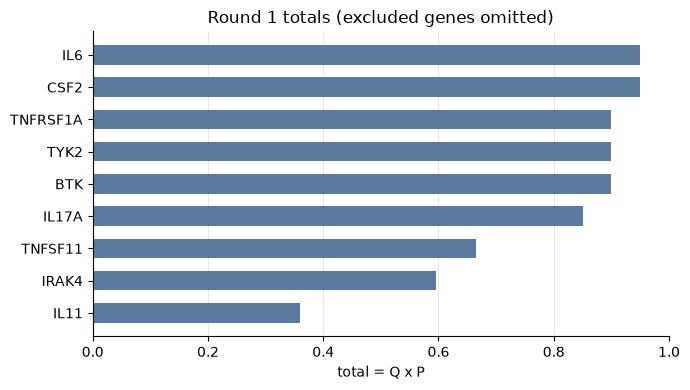

In [14]:
t = pd.DataFrame(score_rows).dropna(subset=["total"]).sort_values("total")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(t["gene"], t["total"], color="#5b7a9d", height=0.6)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.set_xlim(0, 1); ax.set_xlabel("total = Q x P"); ax.set_title("Round 1 totals (excluded genes omitted)")
ax.grid(axis="x", color="#ddd", linewidth=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## ステップ4：上位どうしの対戦比較（左右を入れ替えて2回）

### このセルがすること：同点の候補に差をつけ、上位3件に反論役を付ける
1. 既知・別枠を除いた候補を総合点順に並べ、上位4件を選びます。
2. 2つずつ「どちらが妥当か」を聞き、左右を入れ替えてもう1回聞きます。2回の答えが同じなら勝ち、違えば引き分け。
3. 勝ち = 1点、引き分け = 0.5点（Copeland 方式）で順位を付けます。
4. 上位3件に「失敗する理由を3つ」を書かせます（反論役）。
5. 停止判定に使う「上位5件の顔ぶれ」を控えます。

In [15]:
ranked1 = [g for g, c in sorted(cands.items(), key=lambda kv: (-(kv[1]["total"] or -1), kv[0]))
           if c["total"] is not None and not c["is_seed"] and c["category"] not in ("known", "excluded")]
top4 = ranked1[:PAIR_TOPK]                                                       # 1.
copeland, duel_log = {g: 0.0 for g in top4}, []
for a, b in itertools.combinations(top4, 2):                                     # 2.
    r1 = next((s for s in parse_genes(generate(PAIRWISE_PROMPT.format(a=a, b=b, **fill)).upper()) if s in (a, b)), "?")
    r2 = next((s for s in parse_genes(generate(PAIRWISE_PROMPT.format(a=b, b=a, **fill)).upper()) if s in (a, b)), "?")
    verdict = r1 if (r1 == r2 and r1 in (a, b)) else "tie"
    if verdict == "tie": copeland[a] += 0.5; copeland[b] += 0.5                 # 3.
    else: copeland[verdict] += 1.0
    duel_log.append({"duel": f"{a} vs {b}", "first": r1, "swapped": r2, "verdict": verdict})
ranking = sorted(copeland.items(), key=lambda kv: (-kv[1], kv[0]))
display(pd.DataFrame(duel_log))
print("Copeland:", ranking)
for g, _ in ranking[:3]:                                                          # 4.
    cands[g]["critique"] = generate(CRITIC_PROMPT.format(gene=g, **fill))
    print(f"critic {g}: {cands[g]['critique']}")
top5_round1 = ranked1[:STOP_TOPK]                                                 # 5.
print("top-5 for stop rule:", top5_round1)

,duel,first,swapped,verdict
0,CSF2 vs BTK,CSF2,BTK,tie
1,CSF2 vs TNFRSF1A,TNFRSF1A,TNFRSF1A,TNFRSF1A
2,CSF2 vs TYK2,CSF2,CSF2,CSF2
3,BTK vs TNFRSF1A,TNFRSF1A,TNFRSF1A,TNFRSF1A
4,BTK vs TYK2,BTK,BTK,BTK
5,TNFRSF1A vs TYK2,TNFRSF1A,TNFRSF1A,TNFRSF1A


Copeland: [('TNFRSF1A', 3.0), ('BTK', 1.5), ('CSF2', 1.5), ('TYK2', 0.0)]
critic TNFRSF1A: Several TNF-blocking drugs already exist, so demonstrating added value over them is difficult. Receptor blockade may not be superior to ligand neutralisation. TNFR1 signalling also mediates host defence.
critic BTK: BTK is expressed in platelets as well as B cells, so bleeding risk exists. Oral BTK inhibitors have shown mixed efficacy in RA trials. Off-target kinase effects.
critic CSF2: Its role may be redundant with other cytokines, so blocking it alone may give a small effect. Phase 3 anti-GM-CSF antibodies have shown insufficient efficacy. Pulmonary alveolar proteinosis is a theoretical risk.
top-5 for stop rule: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']


## ステップ5：2回目のループ（新しい候補は ×0.7）

### このセルがすること：1回目を通った候補を新しい種にして、ステップ2〜3と同じ処理を行い、停止を判定する
- 処理はステップ2（拡張）・ステップ3（注釈・検証・採点）と同じコードです。違いは `round = 2` にすることで、総合点に減衰 0.7 が掛かる点だけです。
- 最後に、上位5件の顔ぶれが1回目と同じなら停止、と判定します。

In [16]:
sources2 = [g for g in new1 if cands[g]["category"] != "excluded"]
new2 = []
for src in sources2:                                                             # --- 拡張（ステップ2と同じ） ---
    src_hops = 0 if src in known else cands[src]["hops"]
    plans = [(PARTNERS_PROMPT, "direct partner", src_hops + 1), (UPSTREAM_PROMPT, "upstream regulator", src_hops + 2),
             (DOWNSTREAM_PROMPT, "downstream effector", src_hops + 2), (MAP_PROMPT, "map neighbour (same family)", src_hops + 2)]
    if cands[src]["stage"]:
        plans.append((SAME_STAGE_PROMPT, f"same stage {cands[src]['stage']}", src_hops + 2))
    for template, how, hops in plans:
        kw = {"gene": src, "stage": STAGE_NAME.get(cands[src]["stage"], ""), "seeds": src}
        for g in parse_genes(generate(template.format(**kw, **fill)))[:8]:
            if g in cands: continue
            cands[g] = {"round": 2, "is_seed": False, "how": f"{src} -> {how} -> {g}", "parent": src, "stage": None, "dir": None,
                        "hops": hops, "vbin": None, "answers": {}, "verified_known": False, "note": "", "contradiction": False, "critique": ""}
            new2.append(g)
for g in new2:                                                                    # --- 注釈と検証（ステップ3と同じ） ---
    c = cands[g]
    st = re.search(r"\bS\d+\b", generate(STAGE_PROMPT.format(gene=g, **fill)).upper())
    c["stage"] = st.group(0) if st and st.group(0) in STAGE_INDEX else None
    c["dir"] = "WORSE" if "WORSE" in generate(DIRECTION_PROMPT.format(gene=g, **fill)).upper() else "BETTER"
    vj = generate(VECTOR_JUDGE.format(gene=g, seeds=", ".join(seeds), **fill)).upper()
    c["vbin"] = "near" if "NEAR" in vj else "mid" if "MID" in vj else "far"
    for q in QUESTIONS:
        if q["qid"] not in QIDS: continue
        vals = [yes_probability(t.format(gene=g, **fill), o) for t in q["texts"] for o in ("yes_first", "no_first")]
        c["answers"][q["qid"]] = sum(vals) / len(vals)
    c["verified_known"] = yes_probability(REVERSE_DRUG.format(gene=g, **fill)) >= 0.5
    if c["verified_known"]: c["note"] = generate(SEED_DRUG_CHECK.format(gene=g, **fill)); known.add(g)
    if c["stage"] and yes_probability(REVERSE_STAGE.format(gene=g, stage=STAGE_NAME[c["stage"]], **fill)) < 0.5:
        c["contradiction"] = True
for g in new2:                                                                    # --- 採点（ステップ3と同じ、round=2 で減衰） ---
    c = cands[g]
    if c["stage"] in STAGE_INDEX and c["dir"] == "BETTER": c["M"], c["excluded"] = 0.0, "opposite direction"
    elif c["stage"] in STAGE_INDEX:
        dist = min(abs(STAGE_INDEX[c["stage"]] - STAGE_INDEX[s]) for s in seed_stages)
        c["M"], c["excluded"] = (M_SAME if dist == 0 else M_ADJ if dist == 1 else M_OFF), ""
    else: c["M"], c["excluded"] = M_OFF, ""
    if c["contradiction"]: c["excluded"] = "contradiction"
    c["N"] = N_DIRECT if c["hops"] <= 1 else N_TWOHOP if c["hops"] == 2 else N_FAR
    c["V"] = {"near": V_NEAR, "mid": V_MID, "far": V_FAR}[c["vbin"]]
    c["P"] = max(c["M"], W_NET * c["N"], W_VEC * c["V"])
    if c["excluded"]: c["Q"], c["total"], c["category"] = None, None, "excluded"; continue
    vals = [(1 - c["answers"][q["qid"]]) if q["invert"] else c["answers"][q["qid"]] for q in QUESTIONS if q["qid"] in QIDS]
    c["Q"] = sum(vals) / len(vals)
    c["total"] = c["Q"] * c["P"] * DAMPING ** (c["round"] - 1)
    c["category"] = ("known" if c["verified_known"] else "moa_near" if c["M"] > 0 else "map_near" if c["V"] >= V_NEAR
                     else "combination" if c["Q"] >= 0.75 else "unsupported")

ranked2 = [g for g, c in sorted(cands.items(), key=lambda kv: (-(kv[1]["total"] or -1), kv[0]))
           if c["total"] is not None and not c["is_seed"] and c["category"] not in ("known", "excluded")]
top5_round2 = ranked2[:STOP_TOPK]
print("new in round 2:", new2)
print("top-5 round 1:", top5_round1); print("top-5 round 2:", top5_round2)
print("stop?", set(top5_round1) == set(top5_round2), "(上位5件が不変なら停止)")
pd.DataFrame([{"gene": g, "round": c["round"], "found via": c["how"], "M": c["M"], "N": c["N"], "V": c["V"], "Q": c["Q"], "P": c["P"],
               "total": None if c["total"] is None else round(c["total"], 3), "category": c["category"]}
              for g, c in sorted(cands.items(), key=lambda kv: (-(kv[1]["total"] or -1), kv[0])) if not c["is_seed"]])

new in round 2: ['MYD88', 'CSF2RA', 'IL6ST']
top-5 round 1: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']
top-5 round 2: ['CSF2', 'BTK', 'TNFRSF1A', 'TYK2', 'IL17A']
stop? True (上位5件が不変なら停止)


,gene,round,found via,M,N,V,Q,P,total,category
0,CSF2,1,TNF -> same stage S4 -> CSF2,1.0,0.5,0.5,0.95,1.0,0.950,moa_near
1,IL6,1,IL6R -> direct partner -> IL6,1.0,1.0,1.0,0.95,1.0,0.950,known
2,BTK,1,MS4A1 -> same stage S2 -> BTK,1.0,0.5,0.5,0.90,1.0,0.900,moa_near
3,TNFRSF1A,1,TNF -> direct partner -> TNFRSF1A,1.0,1.0,0.5,0.90,1.0,0.900,moa_near
4,TYK2,1,JAK1 -> direct partner -> TYK2,1.0,1.0,1.0,0.90,1.0,0.900,moa_near
5,IL17A,1,TNF -> same stage S4 -> IL17A,1.0,0.5,0.5,0.85,1.0,0.850,moa_near
6,CSF2RA,2,CSF2 -> direct partner -> CSF2RA,1.0,0.0,0.5,0.95,1.0,0.665,moa_near
7,TNFSF11,1,TNF -> downstream effector -> TNFSF11,0.7,0.5,0.0,0.95,0.7,0.665,known
8,IRAK4,1,TNF -> upstream regulator -> IRAK4,0.7,0.5,0.5,0.85,0.7,0.595,moa_near
9,IL6ST,2,IL6 -> direct partner -> IL6ST,1.0,1.0,1.0,0.80,1.0,0.560,moa_near


## ステップ6：4つに分けて、根拠の鎖を付ける

### このセルがすること：最終的な分類表と、各候補の「見つかった経路・段階・向き」を出す

In [17]:
CAT_JA = {"known": "既知（直接の関連が確認された）", "moa_near": "しくみ（MoA）が近い候補", "map_near": "地図（ベクトル）が近い候補",
          "combination": "組み合わせの候補", "excluded": "別枠（逆向き・矛盾）", "unsupported": "根拠なし"}
by_cat = {}
for g, c in sorted(cands.items(), key=lambda kv: (-(kv[1]["total"] or 0), kv[0])):
    by_cat.setdefault(c["category"], []).append(g)
display(pd.DataFrame([{"category": CAT_JA[k], "genes": ", ".join(v)} for k, v in by_cat.items()]))
for g in ranked2:
    c = cands[g]
    print(f"{g:9s} {c['how']}; stage {c['stage']} ({c['dir']}); {c['note'].strip() or 'no approved drug for this indication'}")

,category,genes
0,しくみ（MoA）が近い候補,"CSF2, BTK, TNFRSF1A, TYK2, IL17A, CSF2RA, IRAK..."
1,既知（直接の関連が確認された）,"IL6, CD80, IL6R, JAK1, MS4A1, TNF, TNFSF11"
2,地図（ベクトル）が近い候補,IL11
3,別枠（逆向き・矛盾）,IL10


CSF2      TNF -> same stage S4 -> CSF2; stage S4 (WORSE); no approved drug for this indication
BTK       MS4A1 -> same stage S2 -> BTK; stage S2 (WORSE); no approved drug for this indication
TNFRSF1A  TNF -> direct partner -> TNFRSF1A; stage S4 (WORSE); no approved drug for this indication
TYK2      JAK1 -> direct partner -> TYK2; stage S5 (WORSE); no approved drug for this indication
IL17A     TNF -> same stage S4 -> IL17A; stage S4 (WORSE); no approved drug for this indication
CSF2RA    CSF2 -> direct partner -> CSF2RA; stage S4 (WORSE); no approved drug for this indication
IRAK4     TNF -> upstream regulator -> IRAK4; stage S3 (WORSE); no approved drug for this indication
IL6ST     IL6 -> direct partner -> IL6ST; stage S4 (WORSE); no approved drug for this indication
IL11      IL6R -> map neighbour (same family) -> IL11; stage None (WORSE); no approved drug for this indication
MYD88     IRAK4 -> upstream regulator -> MYD88; stage S3 (WORSE); no approved drug for this indication


## 検証1：減衰 0.7 と停止ルールは混ざっている

2回目の候補の総合点は最大 `Q×P×0.7 ≤ 0.7`。1回目の上位5件の最低点（0.85）を超えられないので、
「上位5件が変わらないので停止」は AI の答えではなく定数の帰結です。

### このセルがすること：減衰だけを変えて総合点を計算し直し、2回目の候補が上位5件に入るかを表にする
- すでに得た Q・P・回数から `Q × P × 減衰^(回数−1)` を計算し直すだけなので、AI には聞き直しません。

In [18]:
rows = []
for d in (0.5, 0.7, 0.9, 1.0):
    totals = {g: c["Q"] * c["P"] * d ** (c["round"] - 1) for g, c in cands.items()
              if c["total"] is not None and not c["is_seed"] and c["category"] not in ("known", "excluded")}
    order = sorted(totals, key=lambda g: (-totals[g], g))
    r2_in_top5 = [g for g in order[:STOP_TOPK] if cands[g]["round"] == 2]
    rows.append({"damping": d, "round-2 genes in top-5": ", ".join(r2_in_top5) or "─",
                 "stop after round 2?": set(order[:STOP_TOPK]) == set(top5_round1),
                 "ranking": " > ".join(f"{g}({totals[g]:.2f})" for g in order)})
pd.DataFrame(rows)

,damping,round-2 genes in top-5,stop after round 2?,ranking
0,0.5,─,True,CSF2(0.95) > BTK(0.90) > TNFRSF1A(0.90) > TYK2...
1,0.7,─,True,CSF2(0.95) > BTK(0.90) > TNFRSF1A(0.90) > TYK2...
2,0.9,CSF2RA,False,CSF2(0.95) > BTK(0.90) > TNFRSF1A(0.90) > TYK2...
3,1.0,CSF2RA,False,CSF2(0.95) > CSF2RA(0.95) > BTK(0.90) > TNFRSF...


## 検証2：ヒト遺伝学の質問（Q6）を足すと順位はどう変わるか

デモの反省点「最上位の CSF2 は第3相で失敗した」に対する改善案です。

### このセルがすること：Q6 を含めて Q を計算し直し、Q1〜Q5 だけの順位と並べる
- 記録の再生では Q6 の値は Claude の判断（未検証・後知恵あり）です。本物のLLMなら6回聞いて平均します。

In [19]:
q6 = next(q for q in QUESTIONS if q["qid"] == "Q6")
totals6 = {}
for g in ranked2:
    c = cands[g]
    if USE_LLM:
        vals6 = [yes_probability(t.format(gene=g, **fill), o) for t in q6["texts"] for o in ("yes_first", "no_first")]
        p6 = sum(vals6) / len(vals6)
    else:
        p6 = RECORDED_ANSWERS[g][5]
    vals = [(1 - c["answers"][q["qid"]]) if q["invert"] else c["answers"][q["qid"]] for q in QUESTIONS if q["qid"] in QIDS] + [p6]
    totals6[g] = (sum(vals) / len(vals)) * c["P"] * DAMPING ** (c["round"] - 1)
order6 = sorted(totals6, key=lambda g: (-totals6[g], g))
pd.DataFrame({"Q1-Q5": [f"{g} ({cands[g]['total']:.2f})" for g in ranked2], "Q1-Q6": [f"{g} ({totals6[g]:.2f})" for g in order6]})

,Q1-Q5,Q1-Q6
0,CSF2 (0.95),TYK2 (0.92)
1,BTK (0.90),CSF2 (0.83)
2,TNFRSF1A (0.90),BTK (0.79)
3,TYK2 (0.90),TNFRSF1A (0.79)
4,IL17A (0.85),IL17A (0.75)
5,CSF2RA (0.66),CSF2RA (0.58)
6,IRAK4 (0.59),IRAK4 (0.52)
7,IL6ST (0.56),IL6ST (0.50)
8,IL11 (0.36),IL11 (0.30)
9,MYD88 (0.32),MYD88 (0.27)


## （任意）本物のLLMの「はい」確率と Claude の判定を比べる

### このセルがすること：`MODEL_PATH` を指定した場合だけ、13遺伝子 × 5問について両者の相関と散布図を出す

In [20]:
if USE_LLM:
    rows = []
    for g, conf in RECORDED_ANSWERS.items():
        for q in QUESTIONS:
            if q["qid"] not in QIDS: continue
            vals = [yes_probability(t.format(gene=g, **fill), o) for t in q["texts"] for o in ("yes_first", "no_first")]
            rows.append({"gene": g, "qid": q["qid"], "claude": conf[int(q["qid"][1]) - 1], "model": sum(vals) / len(vals)})
    cmp = pd.DataFrame(rows)
    print("Pearson r:", round(cmp["claude"].corr(cmp["model"]), 3))
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(cmp["claude"], cmp["model"], s=40, color="#5b7a9d", alpha=0.7)
    ax.plot([0, 1], [0, 1], color="#999", linewidth=1, linestyle="--")
    ax.set_xlabel("Claude confidence"); ax.set_ylabel("model p_yes"); ax.set_title("per question")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    plt.tight_layout(); plt.show()
    display(cmp.pivot(index="gene", columns="qid", values="model").round(2))
else:
    print("MODEL_PATH が未指定のためスキップ。GGUF を指定して、設定のセルから再実行してください。")

MODEL_PATH が未指定のためスキップ。GGUF を指定して、設定のセルから再実行してください。
